In [32]:
import torch
import torchvision
from torchvision import datasets, models, transforms
import torch.nn as nn
import torch.optim as optim
import time
import os
import copy
import torch.nn.functional as F
from pathlib import Path
import math, time, copy, random
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
SEED = 32
random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
EPOCHS = 20
LEARNING_RATE = 0.01
AUX_WEIGHT = 0.3

In [5]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465), (0.247,0.243,0.261))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465), (0.247,0.243,0.261))
])

In [6]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:03<00:00, 42.8MB/s]


In [7]:

def train_one_epoch(model, loader, criterion, optimizer, device, aux_weight=0.0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        if isinstance(outputs, tuple):
            main_out = outputs[0]
            loss = criterion(main_out, y)
            for aux_out in outputs[1:]:
                if aux_out is not None and aux_weight > 0.0:
                    loss += aux_weight * criterion(aux_out, y)
            preds = main_out.argmax(1)
        else:
            loss = criterion(outputs, y)
            preds = outputs.argmax(1)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

In [8]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    import torch
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss = criterion(outputs, y)
            total_loss += loss.item() * x.size(0)
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

In [9]:
def train_model(model, trainloader, testloader, epochs, lr, aux_weight=0.0):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, trainloader, criterion, optimizer, device, aux_weight)
        val_loss, val_acc = evaluate(model, testloader, criterion, device)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | TrainAcc={tr_acc:.3f} | ValAcc={val_acc:.3f} | TrainLoss={tr_loss:.3f}| ValidationLoss={val_loss:.3f}")


    return model, train_losses, val_losses, train_accs, val_accs

In [10]:
def plot_curves(train_acc, val_acc, train_loss, val_loss, title):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,4))
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.legend(); plt.title(f'{title} Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True, alpha=0.3); plt.show()
    plt.figure(figsize=(5,4))
    plt.plot(train_acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.legend(); plt.title(f'{title} Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(True, alpha=0.3); plt.show()


In [11]:
def test_accuracy(model, loader, device=device):
    model.eval(); correct, total = 0, 0
    import torch
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            preds = outputs.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total
    print(f"Test Accuracy: {acc*100:.2f}%")
    return acc

In [20]:
def save_model(model, name="model", folder="saved_models"):
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{name}.pth")
    torch.save(model.state_dict(), path)
    print(f"✅ Model saved to {path}")


In [21]:
def load_model(model_class, name="model", folder="saved_models", map_location=None):
    path = os.path.join(folder, f"{name}.pth")
    model = model_class()
    model.load_state_dict(torch.load(path, map_location=map_location or device))
    model.to(device)
    print(f"✅ Model loaded from {path}")
    return model

In [ ]:
def to_float_list(seq):
    result = []
    for item in seq:
        if hasattr(item, "detach"):  # Case 1: Tensor
            result.append(item.detach().cpu().numpy().item()
                          if item.numel() == 1
                          else float(item.mean().cpu().numpy()))
        elif callable(item):         # Case 2: Method or function
            result.append(np.nan)
        else:                        # Case 3: Already float/int
            result.append(float(item))
    return result

In [57]:
def visualize_model_predictions(model, testloader, class_names, device=None, num_samples=10):

    model.eval()
    if device:
        model.to(device)


    images, labels = next(iter(testloader))
    images = images[:num_samples]
    labels = labels[:num_samples]

    if device:
        images = images.to(device)


    with torch.no_grad():
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1).cpu().numpy()


    plt.figure(figsize=(2.5 * num_samples, 4))
    for i in range(num_samples):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)

        true_idx = labels[i].item()
        pred_idx = predictions[i]
        color = 'green' if pred_idx == true_idx else 'red'

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}", color=color)

    plt.tight_layout()
    plt.show()


    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            if device:
                images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    print(f"\nFinal test accuracy: {test_acc:.4f}")



## AlexNet

In [13]:
class AlexNetModule(nn.Module):

    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.features = nn.Sequential(
          nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(kernel_size=2, stride=2),

          nn.Conv2d(64, 192, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(kernel_size=2, stride=2),

          nn.Conv2d(192, 384, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(384, 256, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.Conv2d(256, 256, kernel_size=3, padding=1),
          nn.ReLU(inplace=True),
          nn.MaxPool2d(kernel_size=2, stride=2),
      )
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))
        self.classifier = nn.Sequential(
          nn.Dropout(),
          nn.Linear(256 * 2 * 2, 4096),
          nn.ReLU(inplace=True),
          nn.Dropout(),
          nn.Linear(4096, 4096),
          nn.ReLU(inplace=True),
          nn.Linear(4096, num_classes),
      )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [14]:
alexnet = AlexNetModule(num_classes=10).to(device)
alexnet, trL_a, vaL_a, trA_a, vaA_a = train_model(alexnet, trainloader, testloader, epochs=20, lr=0.01, aux_weight=0.0)

Epoch 1/20 | TrainAcc=0.142 | ValAcc=0.236 | TrainLoss=2.249| ValidationLoss=2.009
Epoch 2/20 | TrainAcc=0.283 | ValAcc=0.343 | TrainLoss=1.864| ValidationLoss=1.752
Epoch 3/20 | TrainAcc=0.381 | ValAcc=0.446 | TrainLoss=1.622| ValidationLoss=1.448
Epoch 4/20 | TrainAcc=0.458 | ValAcc=0.522 | TrainLoss=1.441| ValidationLoss=1.283
Epoch 5/20 | TrainAcc=0.529 | ValAcc=0.584 | TrainLoss=1.284| ValidationLoss=1.149
Epoch 6/20 | TrainAcc=0.587 | ValAcc=0.641 | TrainLoss=1.140| ValidationLoss=1.011
Epoch 7/20 | TrainAcc=0.627 | ValAcc=0.626 | TrainLoss=1.032| ValidationLoss=1.037
Epoch 8/20 | TrainAcc=0.661 | ValAcc=0.692 | TrainLoss=0.941| ValidationLoss=0.883
Epoch 9/20 | TrainAcc=0.683 | ValAcc=0.697 | TrainLoss=0.881| ValidationLoss=0.851
Epoch 10/20 | TrainAcc=0.710 | ValAcc=0.737 | TrainLoss=0.819| ValidationLoss=0.765
Epoch 11/20 | TrainAcc=0.733 | ValAcc=0.739 | TrainLoss=0.755| ValidationLoss=0.749
Epoch 12/20 | TrainAcc=0.750 | ValAcc=0.762 | TrainLoss=0.718| ValidationLoss=0.682
E

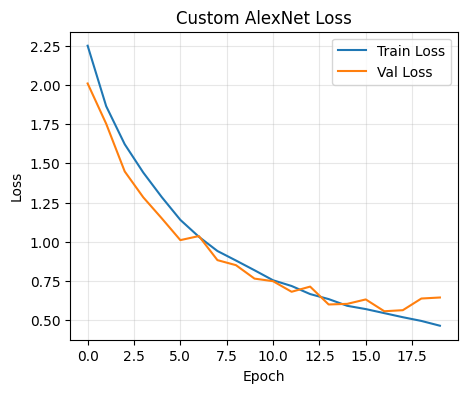

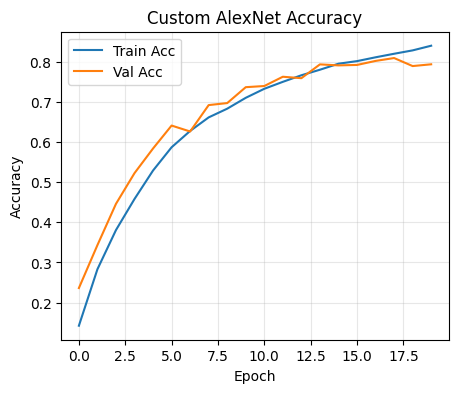

In [15]:
plot_curves(trA_a, vaA_a, trL_a, vaL_a, "Custom AlexNet")

In [16]:
alex_acc = test_accuracy(alexnet, testloader)

Test Accuracy: 79.35%


In [22]:
save_model(alexnet, "alexnet_cifar10_custom")

✅ Model saved to saved_models/alexnet_cifar10_custom.pth


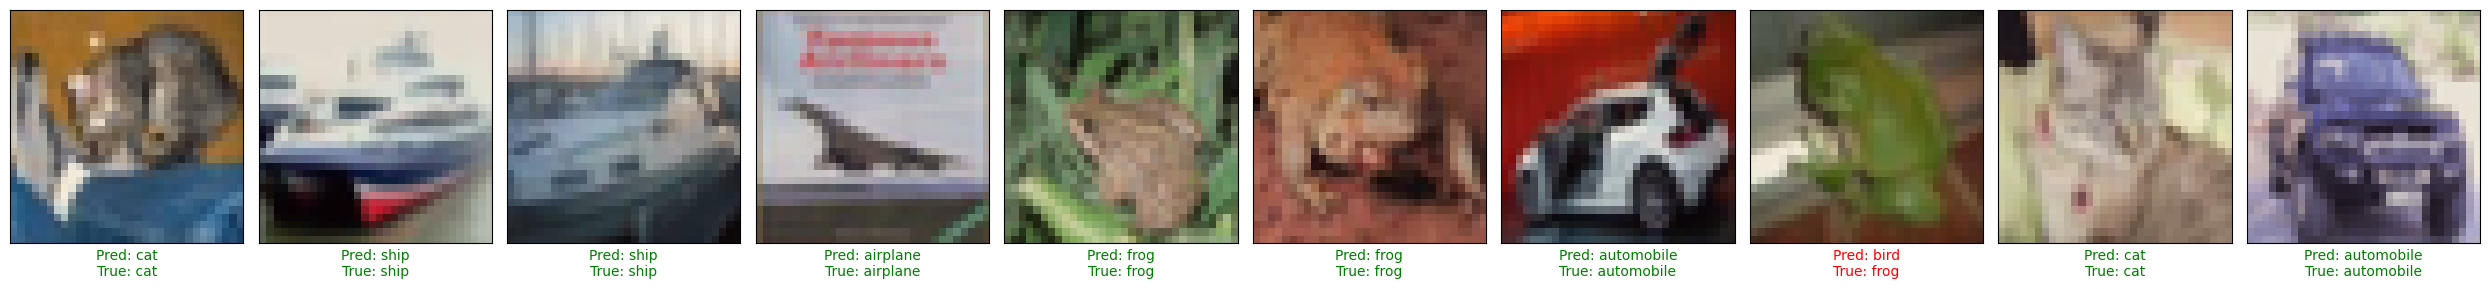


Final test accuracy: 0.7935


In [58]:
class_names = testset.classes
visualize_model_predictions(alexnet, testloader, class_names, device=device, num_samples=10)

## VGG Net

In [17]:
class VGG16CIFAR10(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Block 1: 3x32x32 -> 64x32x32 -> 64x32x32 -> 64x16x16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2: 64x16x16 -> 128x16x16 -> 128x16x16 -> 128x8x8
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 3: 128x8x8 -> 256x8x8 -> 256x8x8 -> 256x8x8 -> 256x4x4
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 4: 256x4x4 -> 512x4x4 -> 512x4x4 -> 512x4x4 -> 512x2x2
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 5: 512x2x2 -> 512x2x2 -> 512x2x2 -> 512x2x2 -> 512x1x1
        self.block5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Classifier: 512x1x1 -> 512 -> 10
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.classifier(x)
        return x

In [18]:
vgg = VGG16CIFAR10(num_classes=10).to(device)
vgg, trL_v, vaL_v, trA_v, vaA_v = train_model(
    vgg, trainloader, testloader,
    epochs=EPOCHS, lr=LEARNING_RATE, aux_weight=0.0
)

Epoch 1/20 | TrainAcc=0.455 | ValAcc=0.593 | TrainLoss=1.485| ValidationLoss=1.141
Epoch 2/20 | TrainAcc=0.644 | ValAcc=0.657 | TrainLoss=1.009| ValidationLoss=1.014
Epoch 3/20 | TrainAcc=0.727 | ValAcc=0.705 | TrainLoss=0.803| ValidationLoss=0.896
Epoch 4/20 | TrainAcc=0.767 | ValAcc=0.741 | TrainLoss=0.685| ValidationLoss=0.789
Epoch 5/20 | TrainAcc=0.800 | ValAcc=0.772 | TrainLoss=0.597| ValidationLoss=0.672
Epoch 6/20 | TrainAcc=0.817 | ValAcc=0.807 | TrainLoss=0.539| ValidationLoss=0.553
Epoch 7/20 | TrainAcc=0.835 | ValAcc=0.782 | TrainLoss=0.493| ValidationLoss=0.666
Epoch 8/20 | TrainAcc=0.846 | ValAcc=0.833 | TrainLoss=0.457| ValidationLoss=0.501
Epoch 9/20 | TrainAcc=0.858 | ValAcc=0.840 | TrainLoss=0.421| ValidationLoss=0.477
Epoch 10/20 | TrainAcc=0.867 | ValAcc=0.848 | TrainLoss=0.393| ValidationLoss=0.457
Epoch 11/20 | TrainAcc=0.878 | ValAcc=0.798 | TrainLoss=0.365| ValidationLoss=0.636
Epoch 12/20 | TrainAcc=0.884 | ValAcc=0.857 | TrainLoss=0.343| ValidationLoss=0.438
E

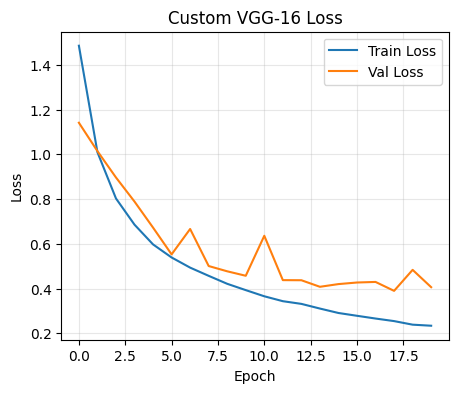

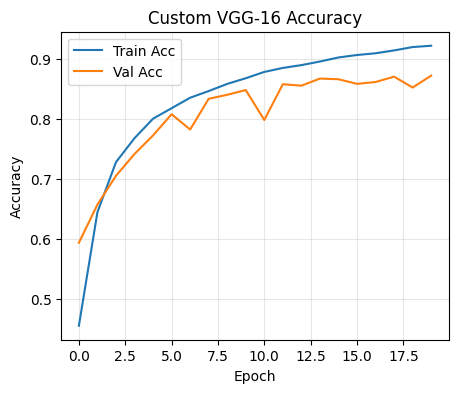

In [23]:
plot_curves(trA_v, vaA_v, trL_v, vaL_v, "Custom VGG-16")


In [24]:
vgg_acc = test_accuracy(vgg, testloader)


Test Accuracy: 87.15%


In [25]:
save_model(vgg, "vgg16_cifar10_custom")

✅ Model saved to saved_models/vgg16_cifar10_custom.pth


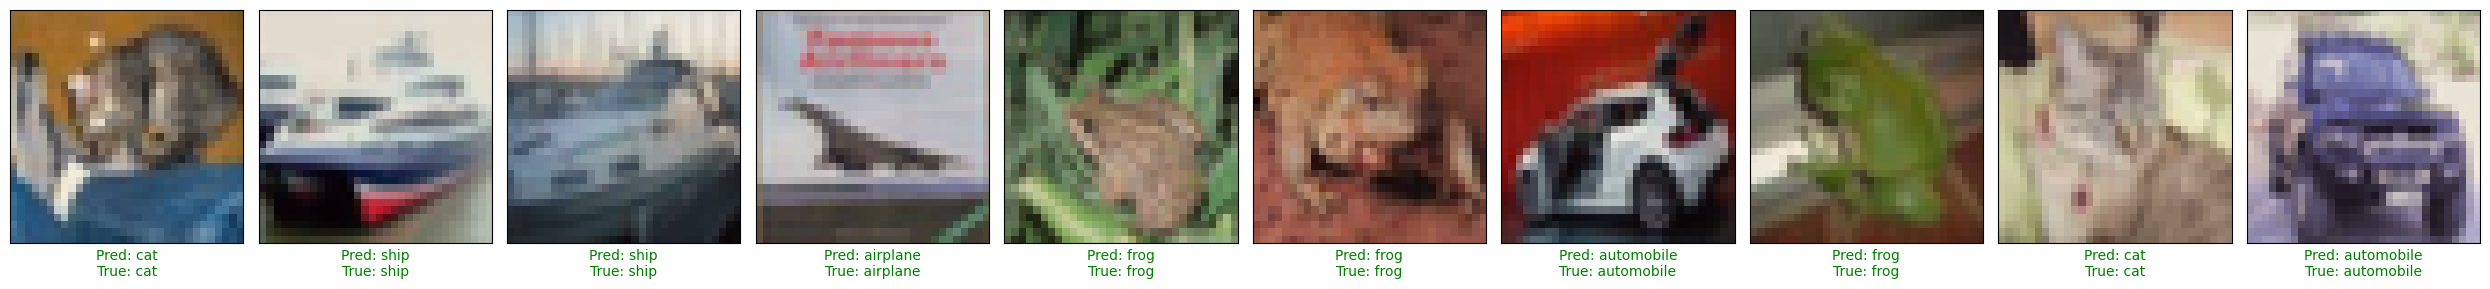


Final test accuracy: 0.8715


In [59]:
class_names=testset.classes
visualize_model_predictions(vgg, testloader, class_names, device=device, num_samples=10)

## miniResNet

In [27]:
class BasicBlock(nn.Module):
    '''
    BasicBlock: Simple residual block with two conv layers
    '''
    EXPANSION = 1
    def __init__(self, in_planes, out_planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_planes)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.shortcut = nn.Sequential()
        # If output size is not equal to input size, reshape it with 1x1 convolution
        if stride != 1 or in_planes != out_planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [28]:
class BottleneckBlock(nn.Module):
    '''
    BottleneckBlock: More powerful residual block with three convs, used for Resnet50 and up
    '''
    EXPANSION = 4
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, self.EXPANSION * planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.EXPANSION * planes)

        self.shortcut = nn.Sequential()
        # If the output size is not equal to input size, reshape it with 1x1 convolution
        if stride != 1 or in_planes != self.EXPANSION * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.EXPANSION * planes,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.EXPANSION * planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [29]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_planes = 64
        # Initial convolution
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        # Residual blocks
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        # FC layer = 1 layer
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512 * block.EXPANSION, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.EXPANSION
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

In [30]:
def ResNet18(num_classes = 10):
    '''
    First conv layer: 1
    4 residual blocks with two sets of two convolutions each: 2*2 + 2*2 + 2*2 + 2*2 = 16 conv layers
    last FC layer: 1
    Total layers: 1+16+1 = 18
    '''
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)


def ResNet34(num_classes):
    '''
    First conv layer: 1
    4 residual blocks with [3, 4, 6, 3] sets of two convolutions each: 3*2 + 4*2 + 6*2 + 3*2 = 32
    last FC layer: 1
    Total layers: 1+32+1 = 34
    '''
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes)


def ResNet50(num_classes = 10):
    '''
    First conv layer: 1
    4 residual blocks with [3, 4, 6, 3] sets of three convolutions each: 3*3 + 4*3 + 6*3 + 3*3 = 48
    last FC layer: 1
    Total layers: 1+48+1 = 50
    '''
    return ResNet(BottleneckBlock, [3, 4, 6, 3], num_classes)


def ResNet101(num_classes = 10):
    '''
    First conv layer: 1
    4 residual blocks with [3, 4, 23, 3] sets of three convolutions each: 3*3 + 4*3 + 23*3 + 3*3 = 99
    last FC layer: 1
    Total layers: 1+99+1 = 101
    '''
    return ResNet(BottleneckBlock, [3, 4, 23, 3], num_classes)


def ResNet152(num_classes = 10):
    '''
    First conv layer: 1
    4 residual blocks with [3, 8, 36, 3] sets of three convolutions each: 3*3 + 8*3 + 36*3 + 3*3 = 150
    last FC layer: 1
    Total layers: 1+150+1 = 152
    '''
    return ResNet(BottleneckBlock, [3, 8, 36, 3], num_classes)

In [31]:
resnet = ResNet18().to(device)
resnet_model, train_losses, val_losses, train_accs, val_accs =train_model(
    resnet, trainloader, testloader,
    epochs=EPOCHS, lr=LEARNING_RATE, aux_weight=0.0
)

Epoch 1/20 | TrainAcc=0.485 | ValAcc=0.564 | TrainLoss=1.415| ValidationLoss=1.269
Epoch 2/20 | TrainAcc=0.671 | ValAcc=0.668 | TrainLoss=0.933| ValidationLoss=1.020
Epoch 3/20 | TrainAcc=0.750 | ValAcc=0.737 | TrainLoss=0.719| ValidationLoss=0.845
Epoch 4/20 | TrainAcc=0.794 | ValAcc=0.798 | TrainLoss=0.591| ValidationLoss=0.603
Epoch 5/20 | TrainAcc=0.822 | ValAcc=0.789 | TrainLoss=0.521| ValidationLoss=0.655
Epoch 6/20 | TrainAcc=0.838 | ValAcc=0.820 | TrainLoss=0.465| ValidationLoss=0.538
Epoch 7/20 | TrainAcc=0.854 | ValAcc=0.828 | TrainLoss=0.419| ValidationLoss=0.510
Epoch 8/20 | TrainAcc=0.868 | ValAcc=0.823 | TrainLoss=0.382| ValidationLoss=0.567
Epoch 9/20 | TrainAcc=0.877 | ValAcc=0.846 | TrainLoss=0.353| ValidationLoss=0.460
Epoch 10/20 | TrainAcc=0.886 | ValAcc=0.865 | TrainLoss=0.329| ValidationLoss=0.413
Epoch 11/20 | TrainAcc=0.896 | ValAcc=0.860 | TrainLoss=0.304| ValidationLoss=0.420
Epoch 12/20 | TrainAcc=0.901 | ValAcc=0.873 | TrainLoss=0.288| ValidationLoss=0.389
E

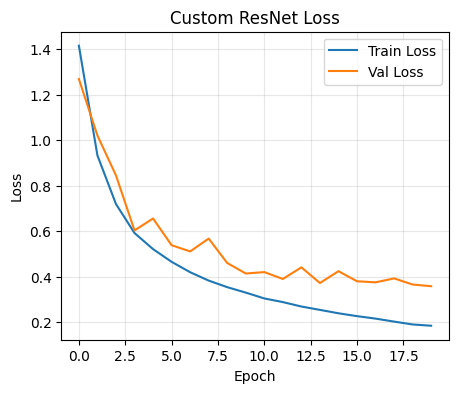

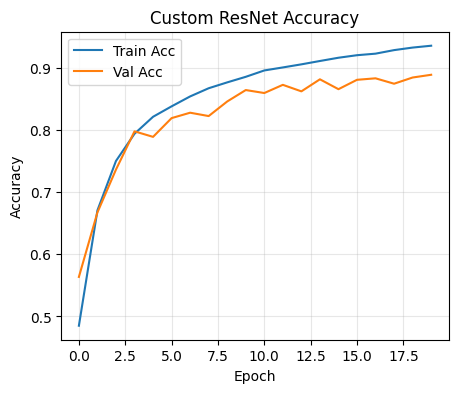

In [33]:

plot_curves(train_accs, val_accs, train_losses, val_losses, "Custom ResNet")

In [34]:
save_model(resnet, "resnet18_cifar10_custom")

✅ Model saved to saved_models/resnet18_cifar10_custom.pth


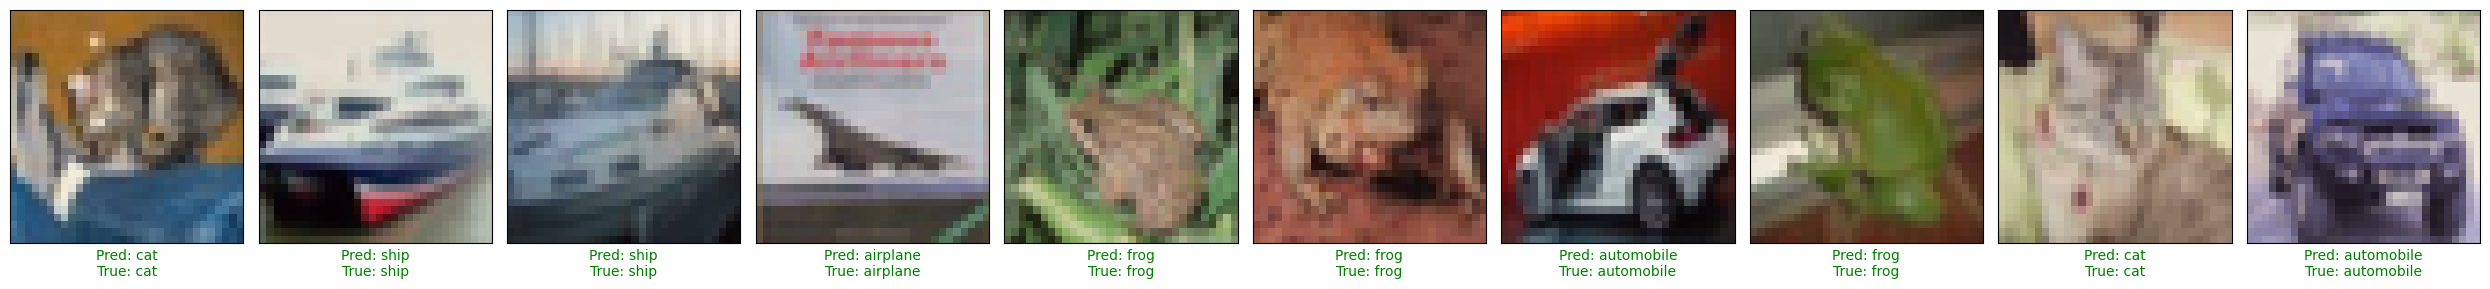


Final test accuracy: 0.8893


In [60]:
class_names=testset.classes
visualize_model_predictions(resnet, testloader, class_names, device=device, num_samples=10)

## Comparison of models and Majority Vote

In [39]:
def evaluate_model(model, dataloader, device=None):

    model.eval()
    if device:
        model.to(device)

    correct = 0
    total = 0
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            if device:
                images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().tolist())
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy, all_preds



In [40]:
alexnet_accuracy, alexnet_predictions = evaluate_model(alexnet, testloader, device=device)
print(f'AlexNet Accuracy: {alexnet_accuracy:.2f}%')

AlexNet Accuracy: 79.35%


In [41]:
vgg_accuracy, vgg_predictions = evaluate_model(vgg, testloader, device=device)
print(f'VGG Accuracy: {vgg_accuracy:.2f}%')

VGG Accuracy: 87.15%


In [42]:
resnet_accuracy, resnet_predictions = evaluate_model(resnet, testloader, device=device)
print(f'ResNet Accuracy: {resnet_accuracy:.2f}%')

ResNet Accuracy: 88.93%


In [45]:
def majority_vote(pred_lists):

    stacked = torch.tensor(pred_lists)  # shape: [num_models, num_samples]
    voted = torch.mode(stacked, dim=0).values
    return voted.tolist()


In [50]:
pred_lists=[alexnet_predictions, vgg_predictions, resnet_predictions]

In [51]:

ensemble_preds = majority_vote([alexnet_predictions, vgg_predictions, resnet_predictions])



In [52]:
true_labels = [label for _, labels in testloader for label in labels]


In [53]:
ensemble_correct = sum([p == t for p, t in zip(ensemble_preds, true_labels)])
ensemble_acc = 100 * ensemble_correct / len(true_labels)
print(f'Majority Vote Ensemble Accuracy: {ensemble_acc:.2f}%')


Majority Vote Ensemble Accuracy: 88.70%


In [75]:
from sklearn.metrics import classification_report


print("\nClassification Report (Majority Vote):")
print(classification_report(true_labels, ensemble_preds, target_names=class_names))



Classification Report (Majority Vote):
              precision    recall  f1-score   support

    airplane       0.84      0.94      0.89      1000
  automobile       0.93      0.97      0.95      1000
        bird       0.75      0.90      0.82      1000
         cat       0.85      0.70      0.77      1000
        deer       0.87      0.90      0.89      1000
         dog       0.93      0.75      0.83      1000
        frog       0.88      0.95      0.91      1000
       horse       0.96      0.90      0.93      1000
        ship       0.94      0.95      0.95      1000
       truck       0.97      0.90      0.93      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [72]:
def visualize_majority_vote_predict(testloader, pred_lists, class_names, num_sample=10):

    images, labels = next(iter(testloader))
    images = images[:num_sample]
    labels = labels[:num_sample]


    voted_preds = torch.mode(torch.tensor([pred[:num_sample] for pred in pred_lists]), dim=0).values.tolist()


    inv_transform = torchvision.transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    images = inv_transform(images)


    plt.figure(figsize=(15, 2.5 * (num_sample // 5 + 1)))
    for i in range(num_sample):
        img = images[i].permute(1, 2, 0).clamp(0, 1)
        true_idx = labels[i].item()
        pred_idx = voted_preds[i]
        color = 'green' if pred_idx == true_idx else 'red'

        plt.subplot(num_sample // 5 + 1, 5, i + 1)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}", color=color)

    plt.tight_layout()
    plt.show()

    total = len(pred_lists[0])
    voted_all = torch.mode(torch.tensor(pred_lists), dim=0).values.tolist()


    all_true = []
    for _, labels in testloader:
        all_true.extend(labels.tolist())

    correct = sum([p == t for p, t in zip(voted_all, all_true)])
    acc = 100 * correct / total
    print(f"\nFinal test accuracy (Majority Vote): {acc:.2f}%")






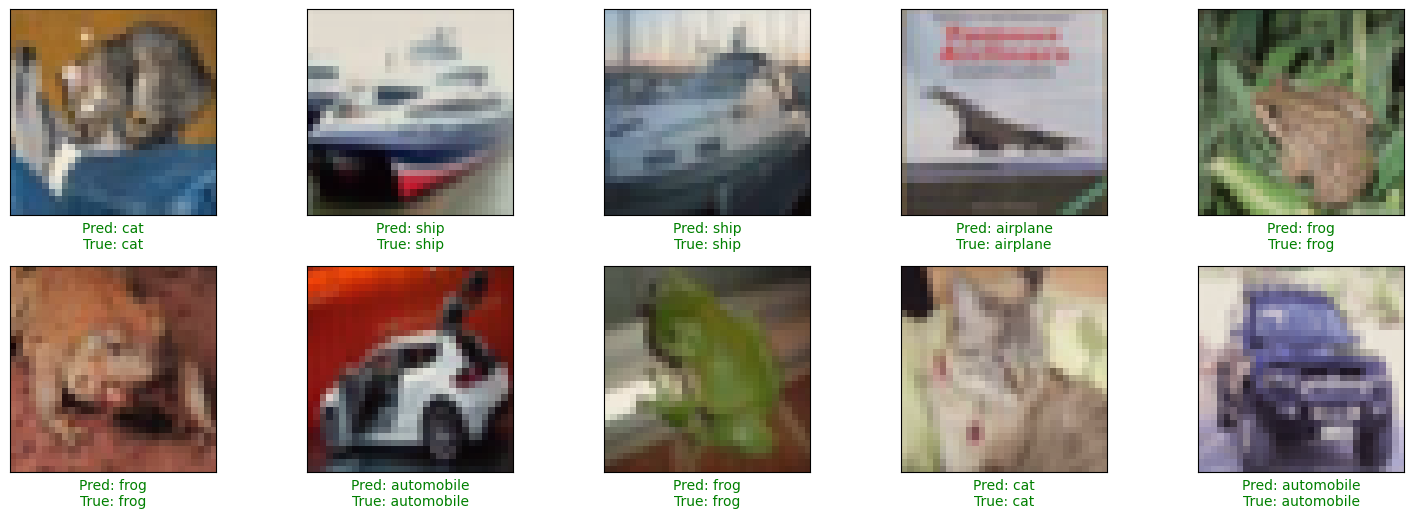


Final test accuracy (Majority Vote): 88.70%


In [74]:
class_names = testset.classes
visualize_majority_vote_predict(testloader, pred_lists=pred_lists, class_names=class_names, num_sample=10)
